#  A Data-Driven Study of the Data Science Job Market  
## Data Preprocessing and Exploratory Data Analysis 

--- 
##  Dataset Used

The dataset used in this project represents information about individuals in the job market. It includes various attributes such as demographic details, educational background, professional experience, and employment-related information.

### Real-World Significance

In the real world, companies collect similar data to understand employee behavior, hiring patterns, and workforce trends. This dataset helps simulate how organizations analyze:

- Why employees switch jobs  
- How experience and education affect career growth  
- The role of training in improving employability  
- Differences in opportunities across cities and company types  

Such insights are extremely useful for companies, policymakers, and job seekers.

##  About the Project

This project focuses on analyzing trends in the AI job market using data-driven techniques. The main idea is to understand how different factors influence employment outcomes and job transitions.

The project is divided into two major stages:

1. **Data Preprocessing**  
   In this stage, the dataset is cleaned and prepared by handling missing values, correcting inconsistencies, and ensuring the data is suitable for analysis.

2. **Exploratory Data Analysis (EDA)**  
   In this stage, different visualizations and statistical techniques are used to explore the dataset, identify patterns, and understand relationships between variables.

   
##  Problem Statement and Dataset Description

This dataset contains information about Data Science job seekers including their education, experience, company details and training hours. The goal is to predict whether a candidate is looking for a job change (target variable).

Attributes:
- enrollee_id : Unique ID of candidate  
- city : City code of candidate  
- city_development_index : Development index of the city  
- gender : Gender of candidate  
- relevent_experience : Relevant experience or not  
- enrolled_university : Type of university enrollment  
- education_level : Education level of candidate  
- major_discipline : Major discipline of candidate  
- experience : Years of experience  
- company_size : Size of current company  
- company_type : Type of current company  
- training_hours : Training hours completed  

Target Variable:
- target : 1 = Looking for job change, 0 = Not looking  

## STEP-1 Initial Data Understanding and Setup

###  What This Step is About

In this step, the dataset is loaded and basic exploration is performed to understand its structure. This includes checking the number of rows and columns, viewing sample data, identifying column names, understanding data types, and analyzing basic statistical properties.

This step helps in getting a clear overview of the dataset, identifying missing values, and understanding which features are numerical or categorical. It acts as the starting point before performing data cleaning and analysis.

###  Real-World Significance

In real-world scenarios, data analysts never directly start modeling without first understanding the data. This step is similar to how a company reviews its records before making decisions.

By analyzing the dataset initially, organizations can:
- Understand the scale and quality of their data  
- Identify incomplete or inconsistent information  
- Recognize important features that influence decisions  

This ensures that further analysis is accurate and meaningful, reducing the chances of incorrect conclusions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("D:\data_science_job.csv")

In [3]:
df.shape

(19158, 13)

In [4]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [5]:
df.columns.tolist()

['enrollee_id',
 'city',
 'city_development_index',
 'gender',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'training_hours',
 'target']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [7]:
df.describe()

,enrollee_id,city_development_index,experience,training_hours,target
count,19158.000000,18679.000000,19093.000000,18392.000000,19158.000000
mean,16875.358179,0.828951,9.928036,65.185787,0.249348
std,9616.292592,0.123334,6.505268,59.885626,0.432647
min,1.000000,0.448000,0.000000,1.000000,0.000000
25%,8554.250000,0.740000,4.000000,23.000000,0.000000
50%,16982.500000,0.903000,9.000000,47.000000,0.000000
75%,25169.750000,0.920000,16.000000,88.000000,0.000000
max,33380.000000,0.949000,20.000000,336.000000,1.000000


## Step 2: Identification of Numerical and Categorical Variables

### What This Step is About

In this step, the dataset is divided into two types of variables based on their data types:

- Numerical variables: These include columns with integer and float values, which represent measurable quantities such as experience, training hours, or city development index.  
- Categorical variables: These include columns with object data types, which represent categories such as gender, education level, company type, etc.

This classification helps in organizing the dataset for further analysis, as different types of variables require different methods of processing and visualization.

In [8]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

numerical_cols
categorical_cols

['city',
 'gender',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'company_size',
 'company_type']

## Initial Observations and Data Issues Identified

Some columns have missing values, particularly in fields like gender, company type, and company size. There is also variation in data distribution across features such as experience and training hours. Additionally, the dataset may contain outliers and possible inconsistencies that need to be addressed before analysis.

### Real-World Significance

In real-world data scenarios, datasets are rarely clean or complete. Initial observations help analysts identify problems early, such as missing information or irregular patterns.

Recognizing these issues is important because:
- Missing data can lead to incorrect conclusions if not handled properly  
- Inconsistent or extreme values can distort analysis  
- Understanding data quality helps in choosing the right preprocessing techniques  

## Step 3: Handling Missing Values and Duplicate Records

### What This Step is About

In this step, the dataset is checked for missing values and duplicate records, and appropriate techniques are applied to handle them.

- First, the number of missing values in each column is identified to understand which features have incomplete data.  
- A heatmap is used to visually represent missing values across the dataset, making it easier to detect patterns or heavily affected columns.  
- Missing values in numerical columns are replaced using the median value, which helps maintain the central tendency without being affected by extreme values.  
- Missing values in categorical columns are replaced using the mode, which represents the most frequently occurring category.  
- Finally, duplicate rows are checked to ensure that repeated data entries do not affect the analysis.

### Real-World Significance

In real-world datasets, missing and duplicate data are very common due to errors in data collection, entry, or system limitations.

Handling missing values is important because:
- Incomplete data can lead to incorrect analysis and biased results  
- Using median and mode ensures that the data remains realistic and does not introduce extreme distortions  

Visualizing missing data helps organizations quickly identify problem areas in their data collection process.

Checking duplicate records is equally important because:
- Duplicate entries can misrepresent actual trends  
- They can lead to overestimation or bias in results  

By performing this step, the dataset becomes cleaner, more reliable, and suitable for accurate analysis and decision-making.

In [9]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

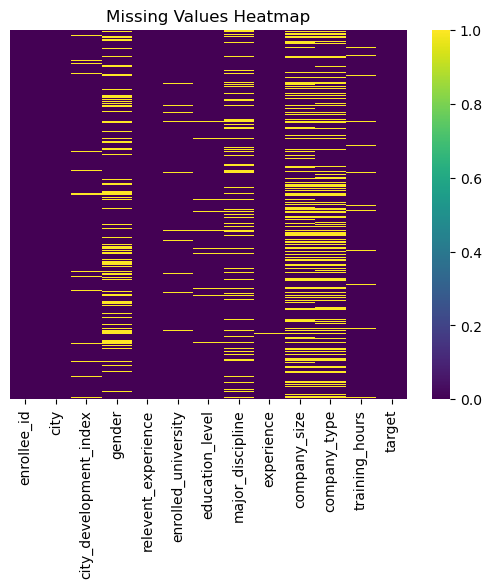

In [10]:
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

In [11]:
numerical_cols = ['city_development_index', 'experience', 'training_hours']
categorical_cols = ['gender', 'enrolled_university', 'education_level',
                    'major_discipline', 'company_size', 'company_type']

num_imputer = SimpleImputer(strategy='median')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [12]:
print(df.duplicated().sum())

0


In [13]:
df.isnull().sum()

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
training_hours            0
target                    0
dtype: int64

## Justification for Imputation Techniques

In this step, missing values in the dataset are handled using appropriate imputation techniques based on the type of data.

- For numerical variables, the median is used to fill missing values because it is not affected by extreme values or outliers.  
- For categorical variables, the mode (most frequent value) is used as it represents the most common category in the data.  

Choosing the right imputation method ensures that the original distribution and characteristics of the data are preserved as much as possible.

## Step 4: Data Cleaning (Incorrect Data Types and Incorrect Values)

### What This Step is About

In this step, data cleaning is performed to correct data types and handle incorrect values present in the dataset.

- Data types of columns such as experience, training hours, and target are converted into appropriate numerical formats to ensure proper analysis.  
- Incorrect or inconsistent values, such as special entries in the experience column (e.g., symbols or non-numeric values), are identified and corrected.  
- Categorical variables are standardized by removing extra spaces and ensuring uniform formatting.  
- Unrealistic or invalid values, such as negative values in numerical columns, are handled to maintain data accuracy.  

This step ensures that the dataset is consistent, structured, and ready for further analysis.

### Real-World Significance

In real-world datasets, incorrect data types and inconsistent values are common due to manual entry errors or system issues.

If not corrected:
- Analysis may produce incorrect results  
- Models may fail or give unreliable predictions  
- Data interpretation becomes misleading  

By cleaning data types and fixing incorrect values, organizations ensure that their data is accurate, reliable, and suitable for decision-making. This step is essential for maintaining the integrity and quality of the analysis.

In [14]:
# Convert experience to numeric (handles errors safely)
df['experience'] = pd.to_numeric(df['experience'], errors='coerce')

# Convert training_hours to numeric
df['training_hours'] = pd.to_numeric(df['training_hours'], errors='coerce')

# Convert city_development_index to float
df['city_development_index'] = df['city_development_index'].astype(float)

# Convert target to integer (classification)
df['target'] = df['target'].astype(int)

In [15]:
# Replace incorrect values
df['experience'] = df['experience'].replace({
    '>20': 21,
    '<1': 0
})

# Convert again after cleaning
df['experience'] = pd.to_numeric(df['experience'], errors='coerce')

In [16]:
# Remove spaces and unify format
df['gender'] = df['gender'].str.strip().str.lower()
df['education_level'] = df['education_level'].str.strip().str.lower()
df['company_type'] = df['company_type'].str.strip().str.lower()

In [17]:
df['gender'] = df['gender'].replace({
    'male': 'Male',
    'female': 'Female',
    'other': 'Other'
})

In [18]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,graduate,STEM,20.0,50-99,pvt ltd,36.0,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,graduate,STEM,15.0,50-99,pvt ltd,47.0,0
2,11561,city_21,0.624,Male,No relevent experience,Full time course,graduate,STEM,5.0,50-99,pvt ltd,83.0,0
3,33241,city_115,0.789,Male,No relevent experience,no_enrollment,graduate,Business Degree,0.0,50-99,pvt ltd,52.0,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,masters,STEM,20.0,50-99,funded startup,8.0,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  19158 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     19158 non-null  object 
 6   education_level         19158 non-null  object 
 7   major_discipline        19158 non-null  object 
 8   experience              19158 non-null  float64
 9   company_size            19158 non-null  object 
 10  company_type            19158 non-null  object 
 11  training_hours          19158 non-null  float64
 12  target                  19158 non-null  int64  
dtypes: float64(3), int64(2), object(8)
memory usage: 1.9+ MB


## Step 5: Outlier Detection and Treatment

### What This Step is About

In this step, outliers in numerical columns are identified and handled using the Interquartile Range (IQR) method.

- For each numerical column, the first quartile (Q1) and third quartile (Q3) are calculated.  
- The Interquartile Range (IQR) is computed as:  
  IQR = Q3 − Q1  
- Lower and upper bounds are determined using:  
  Lower Bound = Q1 − 1.5 × IQR  
  Upper Bound = Q3 + 1.5 × IQR  

- Data points falling outside these bounds are considered outliers and are counted.  
- To handle outliers, values are capped within the lower and upper limits using clipping.  
- After treatment, outliers are checked again to confirm their reduction.
- 
### Real-World Significance

In real-world datasets, outliers can occur due to errors, unusual behavior, or rare events.

If not handled properly:
- They can distort statistical measures like mean and variance  
- They can negatively impact model performance  
- They may lead to misleading insights  

Using the IQR method helps in identifying extreme values in a systematic way. Instead of removing data, clipping ensures that values remain within a reasonable range while preserving the dataset size.

This approach is commonly used in industries where extreme values may exist but should not dominate the analysis, such as salary data, experience levels, or training metrics.

In [21]:
for col in ['city_development_index', 'experience', 'training_hours']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} — Outliers: {len(outliers)}")

city_development_index — Outliers: 17
experience — Outliers: 0
training_hours — Outliers: 1027


In [22]:
for col in ['city_development_index', 'experience', 'training_hours']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

In [23]:
for col in ['city_development_index', 'experience', 'training_hours']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} — Outliers: {len(outliers)}")

city_development_index — Outliers: 0
experience — Outliers: 0
training_hours — Outliers: 0


## Step 6: Data Wrangling and Feature Engineering

### What This Step is About

In this step, data wrangling techniques are applied to transform and analyze the dataset for deeper insights.

- Grouping operations are performed to calculate average values, such as mean training hours by education level and job change rate by gender.  
- Multi-level grouping is used to analyze relationships between multiple variables, such as city and experience with respect to job change.  
- Aggregation functions are applied to summarize data, including average experience, training hours, and target values for different company sizes.  
- Frequency counts are used to understand the distribution of categorical variables like company type.  
- Cross-tabulation and pivot tables are used to analyze relationships between education level, company type, and job change behavior.  
- A new feature called experience level is created by categorizing years of experience into groups such as Fresher, Junior, Mid, and Senior.  
- Filtering is applied to identify specific groups, such as cities where the job change rate is high.

This step enhances the dataset by creating meaningful groupings and summaries that make patterns easier to analyze.

### Real-World Significance

In real-world scenarios, raw data is often not directly useful for decision-making. Data wrangling helps convert raw data into structured and meaningful information.

- Grouping and aggregation allow organizations to understand trends across different categories, such as which education levels or company sizes are associated with higher job switching.  
- Feature engineering, such as creating experience levels, simplifies complex numerical data into interpretable categories that are easier to analyze and communicate.  
- Pivot tables and summaries help decision-makers compare multiple factors at once, which is essential for strategic planning.  
- Filtering helps identify high-risk or high-opportunity segments, such as cities with high employee turnover.  

These techniques are widely used in industry to extract actionable insights and support data-driven decision-making.

In [24]:
df.groupby('education_level')['training_hours'].mean()

education_level
graduate          61.414248
high school       62.922657
masters           59.585875
phd               61.263285
primary school    57.886364
Name: training_hours, dtype: float64

## Insight

The average training hours vary across different education levels, indicating differences in skill development efforts.  
This suggests that candidates with certain educational backgrounds may invest more in training to improve their career opportunities.

In [25]:
df.groupby('gender')['target'].mean()

gender
Female    0.263328
Male      0.248237
Other     0.261780
Name: target, dtype: float64

## Insight

The average target value across genders shows the proportion of candidates from each gender who are likely to switch jobs.  
This helps in understanding differences in job change behavior across genders in the dataset.

In [26]:
df.groupby(['city', 'experience'])['target'].mean()

city     experience
city_1   2.0           1.000000
         3.0           0.000000
         4.0           0.000000
         5.0           0.000000
         6.0           0.333333
                         ...   
city_99  15.0          0.000000
         16.0          0.000000
         17.0          0.000000
         18.0          0.000000
         20.0          0.200000
Name: target, Length: 1694, dtype: float64

## Insight

The job change rate varies across different combinations of city and experience levels.  
This indicates that both location and experience together influence a candidate’s decision to switch jobs.

In [27]:
df.groupby('company_size').agg({
    'experience': 'mean',
    'training_hours': 'mean',
    'target': 'mean'
})

,experience,training_hours,target
company_size,,,
10/49,9.298436,62.015636,0.233855
100-500,10.912096,59.683781,0.161416
1000-4999,11.943524,60.907380,0.150602
10000+,11.299653,59.897969,0.190688
50-99,8.968850,61.582641,0.327569
500-999,11.060433,60.125428,0.173318
5000-9999,11.412078,62.090586,0.181172
<10,9.709480,61.757645,0.171254


## Insight

The average experience, training hours, and job change rate differ across company sizes.  
This indicates that company size plays a role in employee skill development and job-switching behavior.

In [28]:
df['company_type'].value_counts()

company_type
pvt ltd                15957
funded startup          1001
public sector            955
early stage startup      603
ngo                      521
other                    121
Name: count, dtype: int64

## Insight

The distribution of company types shows which types of organizations are most common in the dataset.  
This helps in understanding the overall composition of the job market and dominant employer categories.

In [29]:
df.groupby(['education_level', 'target']).size()

education_level  target
graduate         0         8709
                 1         3349
high school      0         1623
                 1          394
masters          0         3426
                 1          935
phd              0          356
                 1           58
primary school   0          267
                 1           41
dtype: int64

In [42]:
def exp_category(x):
    if x < 2:
        return 'Fresher'
    elif x < 5:
        return 'Junior'
    elif x < 10:
        return 'Mid'
    else:
        return 'Senior'

df['exp_level'] = df['experience'].apply(exp_category)

In [43]:
df.groupby('exp_level')['target'].mean() *100

exp_level
Fresher    43.884220
Junior     33.702369
Mid        26.969752
Senior     17.380788
Name: target, dtype: float64

## Insight

The job change rate varies across different experience levels such as Fresher, Junior, Mid, and Senior.  
This indicates that experience level plays an important role in influencing a candidate’s likelihood of switching jobs.

## Step 7: Feature Engineering

### What This Step is About

In this step, new features are created from existing data to improve the quality and interpretability of the dataset.

- The continuous variable "experience" is converted into categorical groups such as Junior, Mid, Senior, and Expert. This helps in simplifying numerical data into meaningful categories.  
- A new binary feature "is_top_city" is created based on the city development index. Cities with a high development index are marked as 1 (top city), while others are marked as 0.  

These transformations help in making the data more structured and suitable for analysis and modeling.

### Real-World Significance

In real-world applications, raw numerical values are often difficult to interpret directly. Converting them into categories helps in better understanding and decision-making.

- Experience categories are commonly used in hiring processes to classify candidates into levels such as junior or senior, making it easier for companies to evaluate profiles.  
- Identifying top cities based on development index helps organizations understand how location influences job opportunities and employee behavior.  

Feature engineering plays a crucial role in enhancing the dataset by making it more meaningful, interpretable, and aligned with real-world decision-making scenarios.

In [34]:
df_processed = df.copy()

df_processed['experience_category'] = pd.cut(df_processed['experience'],
                                    bins=[-1, 5, 10, 15, 20],
                                    labels=['Junior', 'Mid', 'Senior', 'Expert'])

df_processed['is_top_city'] = df_processed['city_development_index'].apply(lambda x: 1 if x >= 0.9 else 0)

## Step 8: Encoding Categorical Variables

### What This Step is About

In this step, categorical variables are converted into numerical format using label encoding.

- Each categorical column is transformed into a new encoded column where categories are assigned numerical values.  
- This conversion is necessary because most machine learning algorithms cannot process non-numeric data directly.  
- The original categorical data is preserved, and new encoded columns are created for further use.

### Real-World Significance

In real-world data analysis and machine learning, data often contains categorical information such as gender, education level, or company type.

Since algorithms work with numerical data:
- Encoding allows categorical information to be used in predictive models  
- It ensures that no important information is lost during conversion  
- It helps systems process and analyze real-world data efficiently  

This step is essential in preparing the dataset for any advanced analysis or model building.

In [35]:
le = LabelEncoder()

for col in categorical_cols:
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col].astype(str))

In [36]:
df_processed.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'training_hours', 'target', 'exp_level', 'experience_category',
       'is_top_city', 'gender_encoded', 'enrolled_university_encoded',
       'education_level_encoded', 'major_discipline_encoded',
       'company_size_encoded', 'company_type_encoded'],
      dtype='object')

In [37]:
df_processed['gender_encoded'].unique()

array([1, 0, 2])

In [38]:
print(df_processed['gender'].nunique())
print(df_processed['gender_encoded'].nunique())

3
3


In [39]:
pd.DataFrame({
    'Original': df_processed['gender'],
    'Encoded': df_processed['gender_encoded']
}).drop_duplicates()

,Original,Encoded
0,Male,1
19,Female,0
47,Other,2


## Justification for Encoding Categorical Variables

Categorical variables are encoded to convert non-numeric data into a numerical format that can be used by machine learning algorithms.  
Label encoding assigns a unique integer to each category while preserving all the information.  
This ensures that categorical features can be effectively used in analysis and model building.

## Step 9: Feature Scaling

### What This Step is About

In this step, numerical features are scaled using standardization.

- Selected numerical columns such as city development index, experience, and training hours are transformed to a common scale.  
- Standard scaling adjusts the data so that it has a mean of 0 and a standard deviation of 1.  
- This ensures that all numerical features contribute equally and are not biased due to differences in their original scales.

### Real-World Significance

In real-world datasets, different features often have different units and ranges. For example, experience may range from 0 to 20, while training hours may go much higher.

If not scaled:
- Features with larger values can dominate the analysis  
- Models may give more importance to certain variables incorrectly  

Feature scaling ensures fairness in analysis and improves the performance of machine learning models. It is widely used in applications such as salary prediction, employee analysis, and recommendation systems.

In [40]:
scaler = StandardScaler()

scale_cols = ['city_development_index', 'experience', 'training_hours']

df_processed[scale_cols] = scaler.fit_transform(df_processed[scale_cols])

## Justification for Using Standardization

Standardization is used to bring all numerical features to a common scale with mean 0 and standard deviation 1.  
It prevents features with larger values from dominating the analysis or model performance.  
This ensures fair comparison and improves the accuracy and stability of machine learning models.

## Step 10: Exploratory Data Analysis (EDA)

### What This Step is About

Exploratory Data Analysis (EDA) is the process of analyzing and visualizing the dataset to understand its patterns, distributions, and relationships between variables. It involves using statistical summaries and graphical representations such as histograms, boxplots, scatter plots, and heatmaps to explore the data in a meaningful way.

EDA helps in identifying trends, detecting outliers, and understanding how different features influence the target variable. It provides a deeper insight into the dataset before applying any machine learning techniques.

### Real-World Significance

In real-world scenarios, EDA is a crucial step for making data-driven decisions. Organizations use EDA to understand employee behavior, job trends, and factors affecting decisions such as job switching.

By analyzing patterns visually, companies can:
- Identify key factors influencing outcomes  
- Detect unusual patterns or anomalies  
- Make informed decisions based on data insights  

EDA ensures that conclusions are based on actual data patterns rather than assumptions, making it an essential step in any data analysis process.

### UNIVARIATE ANALYSIS

## Figure 1: Distribution of Target Variable (Job Change)

### Insights

This plot shows the distribution of candidates who are looking for a job change versus those who are not. It helps in identifying whether the dataset is balanced or imbalanced. A higher number of one class indicates imbalance, which can affect model performance. It suggests how common job-switching behavior is among candidates. This insight is important for understanding overall trends in the job market.

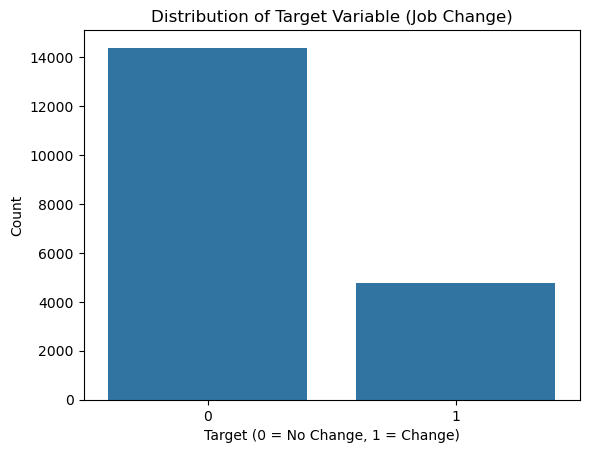

In [41]:
plt.figure()
sns.countplot(x='target', data=df)
plt.title("Distribution of Target Variable (Job Change)")
plt.xlabel("Target (0 = No Change, 1 = Change)")
plt.ylabel("Count")
plt.show()

## Figure 2: Distribution of Training Hours

### Insights

This plot shows how training hours are distributed among candidates. It helps in understanding whether most candidates have low, moderate, or high training hours. The presence of skewness indicates that only a few candidates have very high training hours. It suggests the overall level of skill development in the dataset. This insight helps in analyzing how training may influence job change behavior.

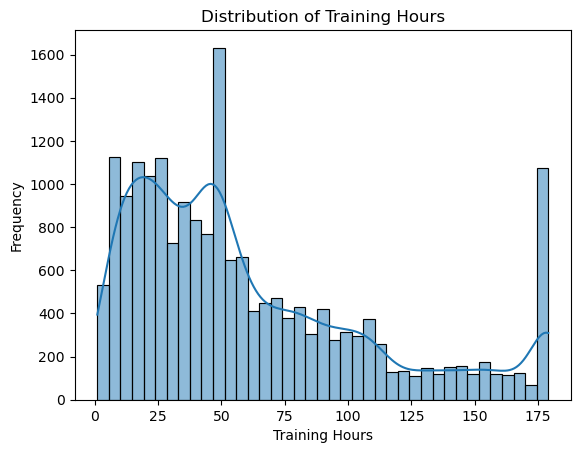

In [40]:
plt.figure()
sns.histplot(df['training_hours'], kde=True)
plt.title("Distribution of Training Hours")
plt.xlabel("Training Hours")
plt.ylabel("Frequency")
plt.show()

## Figure 3: Density of City Development Index

### Insights

This plot shows the distribution of city development levels among candidates. It helps in understanding whether most candidates belong to highly developed or less developed cities. The density pattern indicates how concentrated the data is across different development levels. It suggests the overall urban development background of the candidates. This insight is useful in analyzing how location may influence job opportunities and job change decisions.

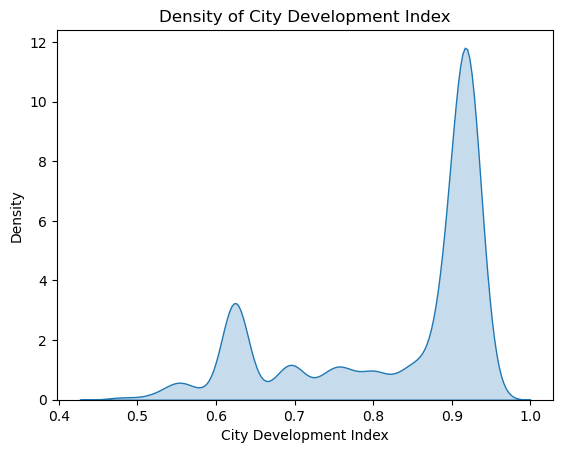

In [41]:
plt.figure()
sns.kdeplot(df['city_development_index'], fill=True)
plt.title("Density of City Development Index")
plt.xlabel("City Development Index")
plt.ylabel("Density")
plt.show()

## Figure 4: Distribution of Experience

### Insights

This plot shows how years of experience are distributed among candidates. It helps in identifying whether the dataset is dominated by freshers or experienced professionals. The distribution indicates the spread and concentration of experience levels. It suggests the overall workforce composition in the dataset. This insight is useful for understanding how experience may influence job change behavior.

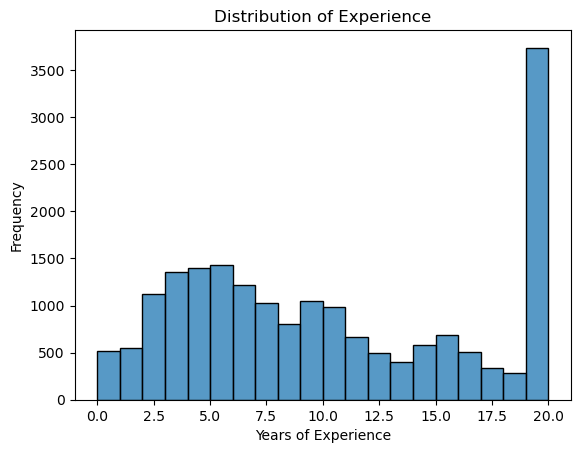

In [42]:
plt.figure()
sns.histplot(df['experience'], bins=20)
plt.title("Distribution of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Frequency")
plt.show()

### BIVARIATE ANALYSIS

## Figure 5: Gender vs Job Change

### Insights

This plot compares job change behavior across different genders. It helps in understanding whether one gender is more likely to switch jobs than others. The distribution shows how job change trends vary within each gender category. It highlights any visible differences or patterns in employment behavior. This insight is useful for analyzing gender-based trends in the job market.

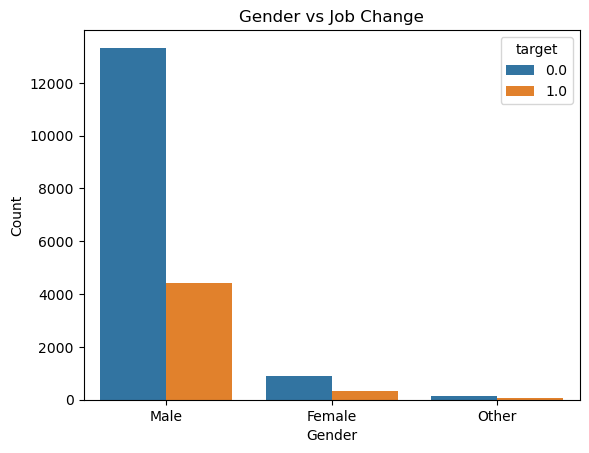

In [43]:
plt.figure()
sns.countplot(x='gender', hue='target', data=df)
plt.title("Gender vs Job Change")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## Figure 6: Experience vs Job Change

### Insights

This plot compares the distribution of experience for candidates who are looking for a job change and those who are not. It helps in understanding how experience levels differ between the two groups. The spread and median values indicate whether less experienced or more experienced candidates tend to switch jobs. It may show that candidates with lower experience are more likely to change jobs. This insight is useful for analyzing how experience influences job-switching behavior.

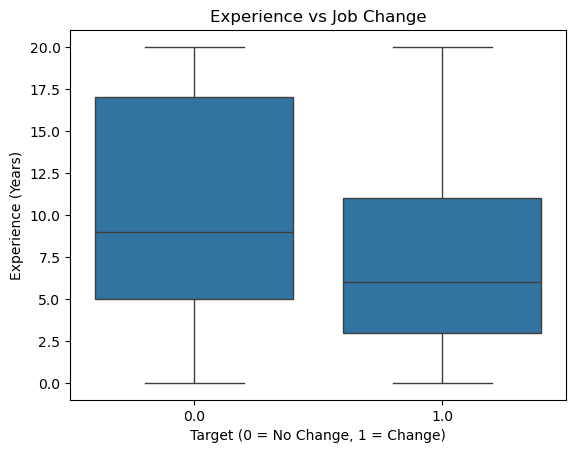

In [44]:
plt.figure()
sns.boxplot(x='target', y='experience', data=df)
plt.title("Experience vs Job Change")
plt.xlabel("Target (0 = No Change, 1 = Change)")
plt.ylabel("Experience (Years)")
plt.show()

## Figure 6: Experience vs Job Change

### Insights

This plot compares the distribution of experience for candidates who are looking for a job change and those who are not. It helps in understanding how experience levels differ between the two groups. The spread and median values indicate whether less experienced or more experienced candidates tend to switch jobs. It may show that candidates with lower experience are more likely to change jobs. This insight is useful for analyzing how experience influences job-switching behavior.

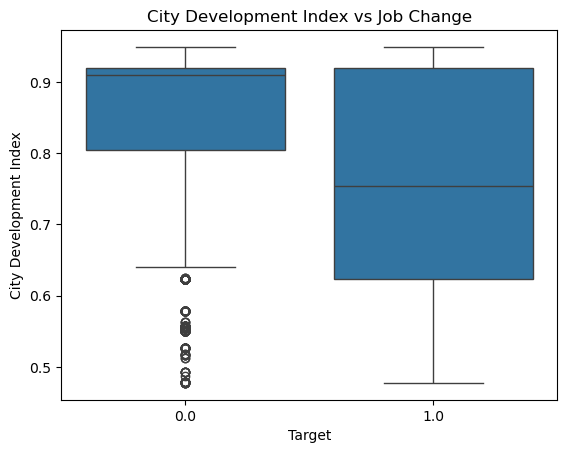

In [45]:
plt.figure()
sns.boxplot(x='target', y='city_development_index', data=df)
plt.title("City Development Index vs Job Change")
plt.xlabel("Target")
plt.ylabel("City Development Index")
plt.show()

## Figure 7: Training Hours vs Job Change

### Insights

This plot compares training hours between candidates who are looking for a job change and those who are not. It helps in understanding whether individuals with higher training tend to switch jobs more. The distribution and median values show differences in skill development levels across both groups. It may indicate that candidates investing more in training are actively seeking better opportunities. This insight is useful for analyzing the role of skill development in job-switching behavior.

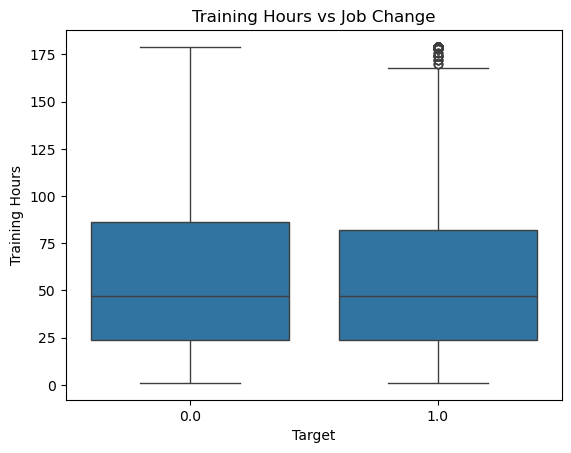

In [46]:
plt.figure()
sns.boxplot(x='target', y='training_hours', data=df)
plt.title("Training Hours vs Job Change")
plt.xlabel("Target")
plt.ylabel("Training Hours")
plt.show()

## Figure 8: Company Size vs Job Change

### Insights

This plot shows how job change behavior varies across different company sizes. It helps in understanding whether employees from smaller or larger companies are more likely to switch jobs. The distribution highlights differences in job-switching patterns based on company size. It may indicate that employees in certain company sizes have higher turnover tendencies. This insight is useful for analyzing how organizational scale influences employee decisions.

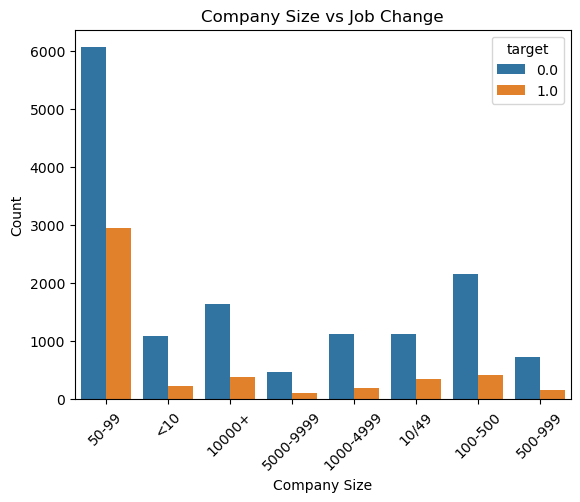

In [47]:
plt.figure()
sns.countplot(x='company_size', hue='target', data=df)
plt.xticks(rotation=45)
plt.title("Company Size vs Job Change")
plt.xlabel("Company Size")
plt.ylabel("Count")
plt.show()

## Figure 9: Education Level vs Job Change

### Insights

This plot shows how job change behavior varies across different education levels. It helps in understanding whether candidates with higher or lower education are more likely to switch jobs. The distribution highlights differences in job-switching trends among various educational backgrounds. It may indicate that certain education levels are associated with higher mobility in the job market. This insight is useful for analyzing the role of education in career decisions.

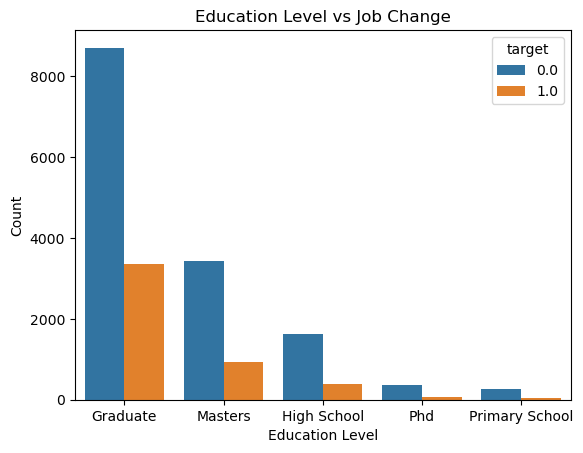

In [48]:
plt.figure()
sns.countplot(x='education_level', hue='target', data=df)
plt.title("Education Level vs Job Change")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()

### MULTIVARIATE ANALYSIS  

## Figure 10: Correlation Heatmap of Numerical Features

### Insights

This plot shows the correlation between numerical features in the dataset. It helps in understanding how strongly different variables are related to each other. Positive and negative correlations indicate the direction of relationships between features. It highlights which features may influence the target variable or each other. This insight is useful for identifying important variables and avoiding redundant features in analysis.

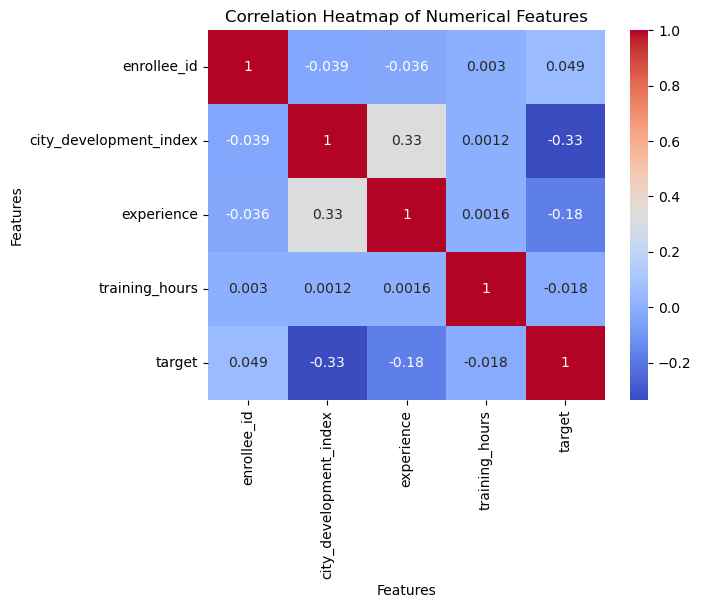

In [49]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

## Figure 11: Experience by Education Level and Job Change

### Insights

This plot shows how experience varies across different education levels while also considering job change behavior. It helps in understanding whether candidates with certain education levels and experience ranges are more likely to switch jobs. The distribution highlights differences in experience within each education category. It may indicate that less experienced individuals within certain education levels tend to change jobs more frequently. This insight is useful for analyzing the combined effect of education and experience on job-switching decisions.

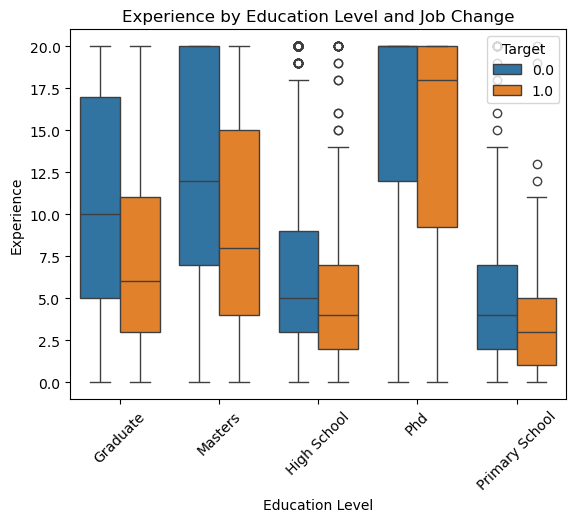

In [63]:
sns.boxplot(x='education_level', y='experience', hue='target', data=df)

plt.legend(title='Target', loc='upper right')  # move position
plt.xticks(rotation=45)
plt.title("Experience by Education Level and Job Change")
plt.xlabel("Education Level")
plt.ylabel("Experience")

plt.show()

## Figure 12: Company Type vs Job Change

### Insights

This plot shows how job change behavior varies across different company types. It helps in understanding whether employees from certain types of organizations are more likely to switch jobs. The distribution highlights differences in job-switching trends among various company categories. It may indicate that some company types experience higher employee turnover. This insight is useful for analyzing how the nature of an organization influences employee decisions.

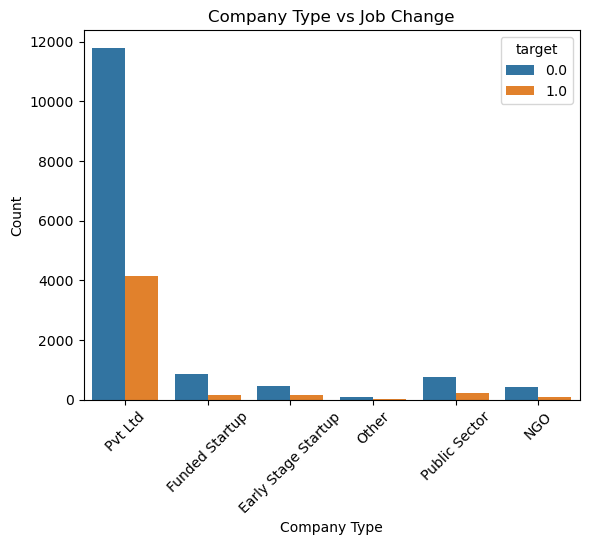

In [53]:
plt.figure()
sns.countplot(x='company_type', hue='target', data=df)
plt.xticks(rotation=45)
plt.title("Company Type vs Job Change")
plt.xlabel("Company Type")
plt.ylabel("Count")
plt.show()

# Conclusion

This study analyzed the AI job market dataset to understand the factors influencing job change behavior. Through data preprocessing and exploratory data analysis, it was observed that variables such as experience, education level, training hours, and company-related factors play a significant role in determining whether a candidate is likely to switch jobs.

The analysis highlighted that candidates with lower experience and higher training engagement tend to show a greater tendency to seek new opportunities. Additionally, factors like company size, company type, and city development level also influence employment trends.

Overall, this project demonstrates how data-driven techniques can be used to extract meaningful insights from real-world datasets. These insights can help organizations improve hiring strategies, employee retention, and workforce planning, while also helping individuals make informed career decisions.